In [1]:
import pandas as pd

df = pd.read_json('/home/bartosz-linux/study/bcmp-networks/logs/T57jOcVpi9.jsonl', lines=True)


In [2]:
df.head()

,source,id,starttime,duration,config_path,ts,action,request_id,old_type,new_type,dest_id
0,INIT,T57jOcVpi9,2024-11-04T20:15:26.399054,60.0,configs/networks/example2.json,NaN,NaN,NaN,NaN,NaN,NaN
1,WS 1,NaN,NaN,NaN,NaN,00:00:185,queued,0.0,NaN,NaN,NaN
2,GN 1,NaN,NaN,NaN,NaN,00:00:185,generated,0.0,NaN,NaN,NaN
3,WS 1,NaN,NaN,NaN,NaN,00:00:185,started,0.0,NaN,NaN,NaN
4,WS 1,NaN,NaN,NaN,NaN,00:01:013,swapped,0.0,type1,type3,NaN


In [3]:
# Convert the timestamp 'ts' column to a standard datetime.timedelta format for easy time calculations
import numpy as np
import datetime as dt

# Convert 'ts' to timedelta
def parse_timestamp(ts):
    try:
        minutes, seconds, milliseconds = map(int, ts.split(':'))
        return dt.timedelta(minutes=minutes, seconds=seconds, milliseconds=milliseconds)
    except:
        return np.nan

df['ts'] = df['ts'].apply(parse_timestamp)

# Filter relevant rows for each calculation by actions
# Extracting queueing and processing stages
queued_df = df[df['action'] == 'queued']
started_df = df[df['action'] == 'started']
processed_df = df[df['action'] == 'processed']

# Calculating average number of requests by class and server
avg_requests_per_class_server = df.groupby(['source', 'new_type'])['request_id'].nunique().groupby(level=0).mean()


# Combining results into a single DataFrame for presentation
results_df = pd.DataFrame({
    'avg_requests_per_class': avg_requests_per_class_server,
}).reset_index()


print(results_df)

  source  avg_requests_per_class
0   WS 1                7.666667
1   WS 2               34.000000
2   WS 3               15.000000
3   WS 4                5.500000
4   WS 5                9.000000


In [ ]:
import pandas as pd
import datetime as dt

ws_df = df[df['source'].str.startswith('WS')]

ws_df['ts'] = ws_df['ts'].apply(lambda x: pd.to_timedelta(x) if pd.notnull(x) else pd.NaT)

# Unikalna liczba zgłoszeń na serwer i klasę
unique_requests_per_class_server = ws_df.groupby(['source', 'new_type'])['request_id'].nunique().reset_index(name="unique_request_count")

# Statystyki dla czasu (min, max) z przeliczonym duration_seconds
timestamp_stats_ws = ws_df.dropna(subset=['ts']).groupby(['source', 'action'])['ts'].agg(['count', 'min', 'max'])
timestamp_stats_ws['duration_seconds'] = (timestamp_stats_ws['max'] - timestamp_stats_ws['min']).dt.total_seconds()

#Liczba wystąpień każdej akcji na serwerach
action_counts_ws = ws_df.groupby(['source', 'action']).size().unstack(fill_value=0).reset_index()

print(unique_requests_per_class_server)



  source new_type  unique_request_count
0   WS 1    type1                    10
1   WS 1    type2                     7
2   WS 1    type3                     6
3   WS 2    type2                    34
4   WS 3    type1                     6
5   WS 3    type3                    24
6   WS 4    type2                     6
7   WS 4    type3                     5
8   WS 5    type3                     9


/tmp/ipykernel_88604/2897742379.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ws_df['ts'] = ws_df['ts'].apply(lambda x: pd.to_timedelta(x) if pd.notnull(x) else pd.NaT)


In [6]:
print(timestamp_stats_ws)


                  count                    min                    max  \
source action                                                           
WS 1   forwarded     23 0 days 00:00:01.013000 0 days 00:00:58.914000   
       processed     23 0 days 00:00:01.013000 0 days 00:00:58.914000   
       queued        28 0 days 00:00:00.185000 0 days 00:00:58.375000   
       rejected      18 0 days 00:00:14.239000 0 days 00:00:49.850000   
       started       24 0 days 00:00:00.185000 0 days 00:00:58.914000   
       swapped       23 0 days 00:00:01.013000 0 days 00:00:58.914000   
WS 2   finished      13 0 days 00:00:05.172000 0 days 00:00:56.753000   
       forwarded     34 0 days 00:00:05.600000 0 days 00:00:59.996000   
       processed     47 0 days 00:00:05.172000 0 days 00:00:59.996000   
       started       47 0 days 00:00:01.836000 0 days 00:00:59.367000   
       swapped       34 0 days 00:00:05.600000 0 days 00:00:59.996000   
WS 3   forwarded     30 0 days 00:00:01.788000 0 da

In [7]:
print(action_counts_ws)

action source  finished  forwarded  processed  queued  rejected  started  \
0        WS 1         0         23         23      28        18       24   
1        WS 2        13         34         47       0         0       47   
2        WS 3         0         30         30       0         0       31   
3        WS 4        16         11         27      34         0       28   
4        WS 5         5          9         14      15         0       15   

action  swapped  
0            23  
1            34  
2            30  
3            11  
4             9  


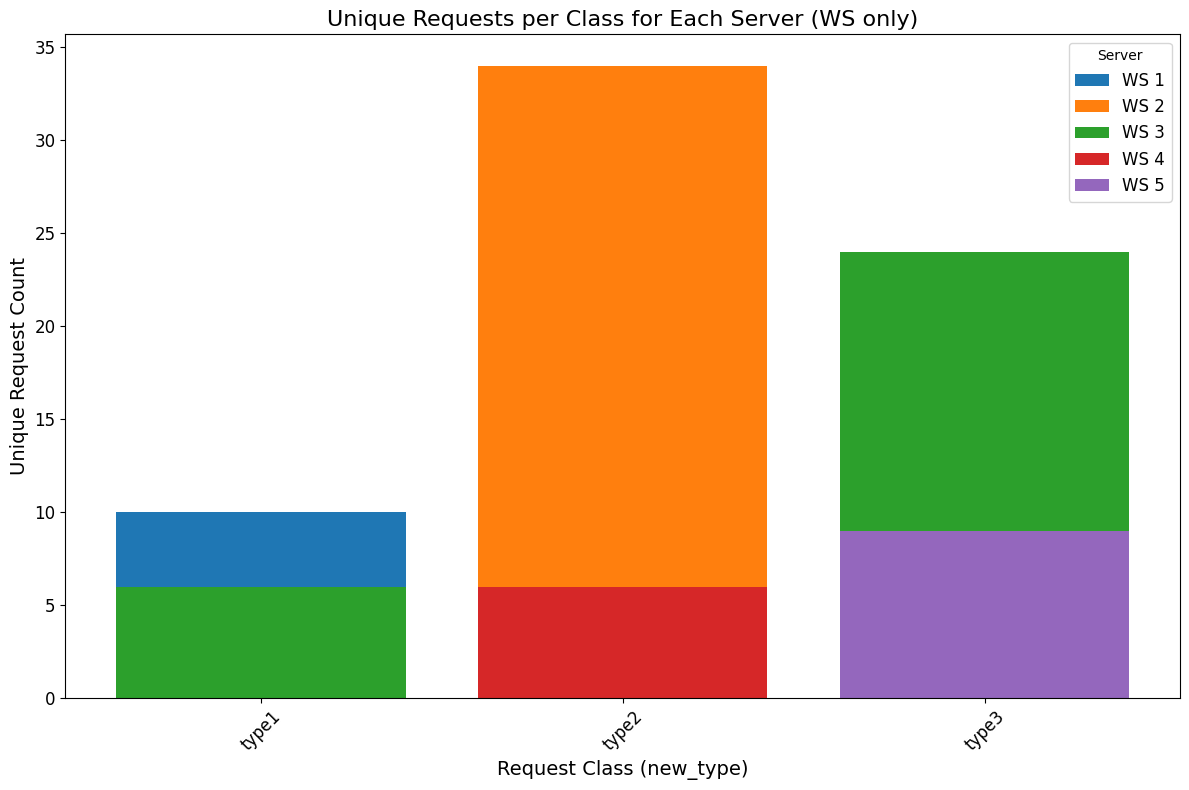

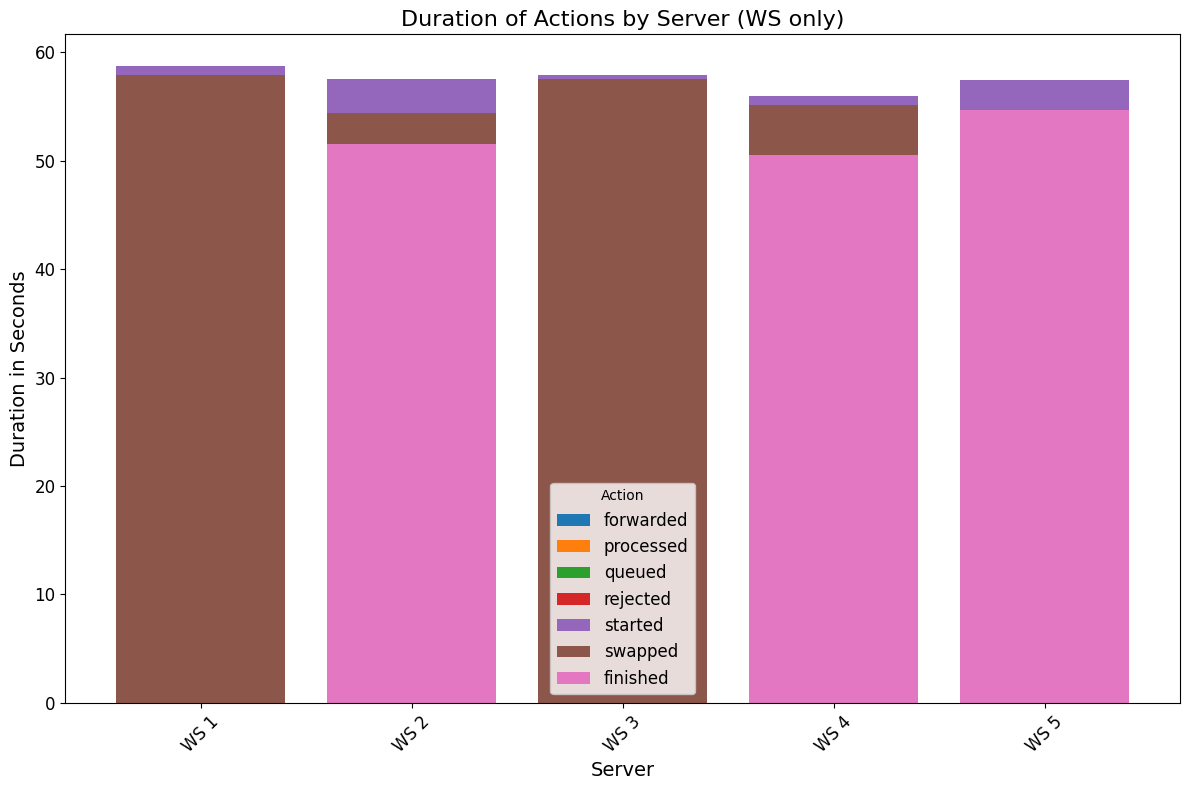

<Figure size 1200x800 with 0 Axes>

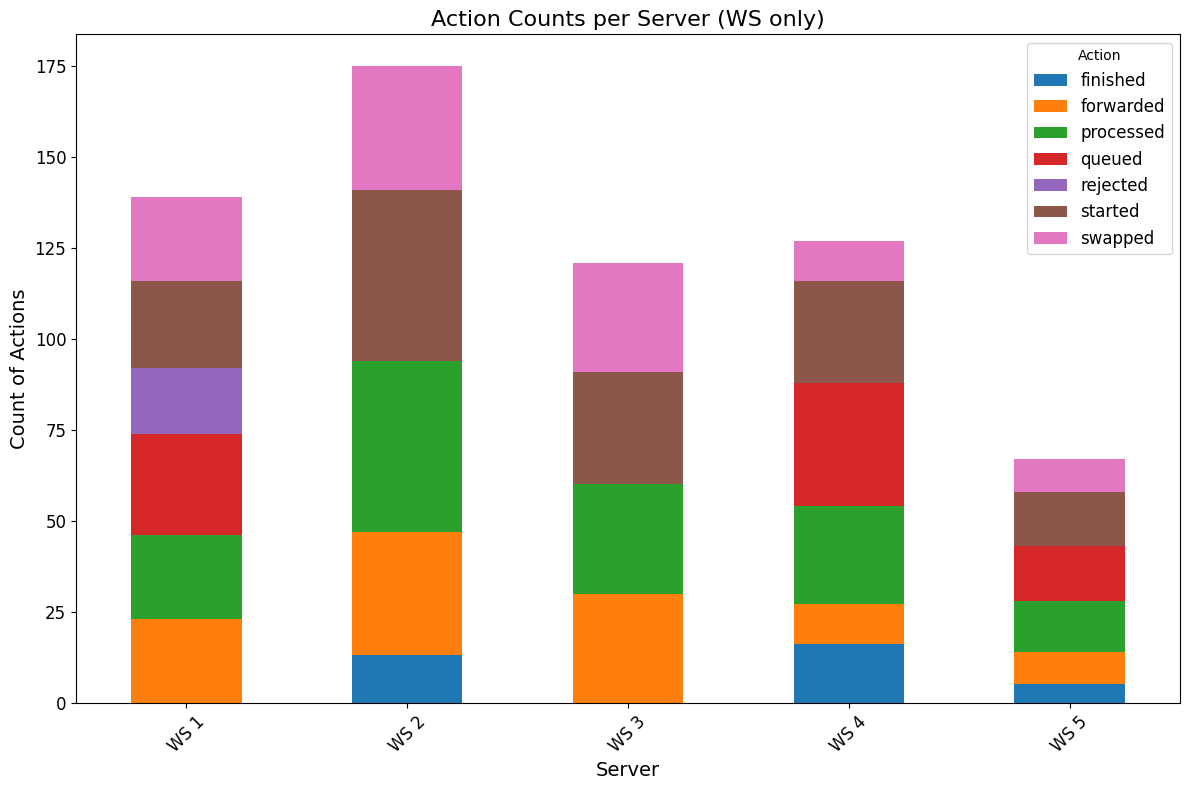

In [8]:
import matplotlib.pyplot as plt

# Re-plotting each of the requested data frames with improved readability

# 1. Bar plot for Unique Requests per Class and Server
plt.figure(figsize=(12, 8))
for server in unique_requests_per_class_server['source'].unique():
    subset = unique_requests_per_class_server[unique_requests_per_class_server['source'] == server]
    plt.bar(subset['new_type'], subset['unique_request_count'], label=server)

plt.title("Unique Requests per Class for Each Server (WS only)", fontsize=16)
plt.xlabel("Request Class (new_type)", fontsize=14)
plt.ylabel("Unique Request Count", fontsize=14)
plt.legend(title="Server", fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 2. Bar plot for Duration of Actions by Server (for WS servers only)
plt.figure(figsize=(12, 8))
for action in timestamp_stats_ws.index.get_level_values('action').unique():
    subset = timestamp_stats_ws.xs(action, level='action')
    plt.bar(subset.index, subset['duration_seconds'], label=action)

plt.title("Duration of Actions by Server (WS only)", fontsize=16)
plt.xlabel("Server", fontsize=14)
plt.ylabel("Duration in Seconds", fontsize=14)
plt.legend(title="Action", fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 3. Stacked bar plot for Action Counts per Server (for WS servers only)
plt.figure(figsize=(12, 8))
action_counts_ws.set_index('source').plot(kind='bar', stacked=True, figsize=(12, 8), legend=True)
plt.title("Action Counts per Server (WS only)", fontsize=16)
plt.xlabel("Server", fontsize=14)
plt.ylabel("Count of Actions", fontsize=14)
plt.legend(title="Action", fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
